In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from __future__ import print_function
from keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
import glob
import skimage.io as io
import skimage.transform as trans
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import matplotlib.image


from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras import backend as keras

In [3]:

os.chdir('/content/drive/My Drive/Colab Notebooks/unet')


In [4]:
def adjustData(img,mask,flag_multi_class,num_class):
    if(flag_multi_class):
        img = img / 255
        mask = mask[:,:,:,0] if(len(mask.shape) == 4) else mask[:,:,0]
        new_mask = np.zeros(mask.shape + (num_class,))
        for i in range(num_class):

            new_mask[mask == i,i] = 1
        new_mask = np.reshape(new_mask,(new_mask.shape[0],new_mask.shape[1]*new_mask.shape[2],new_mask.shape[3])) if flag_multi_class else np.reshape(new_mask,(new_mask.shape[0]*new_mask.shape[1],new_mask.shape[2]))
        mask = new_mask
    elif(np.max(img) > 1):
        img = img / 255
        mask = mask /255
        mask[mask > 0.5] = 1
        mask[mask <= 0.5] = 0
    return (img,mask)



def trainGenerator(batch_size,train_path,image_folder,mask_folder,aug_dict,image_color_mode = "grayscale",
                    mask_color_mode = "grayscale",image_save_prefix  = "image",mask_save_prefix  = "mask",
                    flag_multi_class = False,num_class = 2,save_to_dir = None,target_size = (256,256),seed = 1):
    '''
    can generate image and mask at the same time
    use the same seed for image_datagen and mask_datagen to ensure the transformation for image and mask is the same
    if you want to visualize the results of generator, set save_to_dir = "your path"
    '''
    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)
    image_generator = image_datagen.flow_from_directory(
        train_path,
        classes = [image_folder],
        class_mode = None,
        color_mode = image_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        save_to_dir = save_to_dir,
        save_prefix  = image_save_prefix,
        seed = seed)
    mask_generator = mask_datagen.flow_from_directory(
        train_path,
        classes = [mask_folder],
        class_mode = None,
        color_mode = mask_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        save_to_dir = save_to_dir,
        save_prefix  = mask_save_prefix,
        seed = seed)
    train_generator = zip(image_generator, mask_generator)
    for (img,mask) in train_generator:
        img,mask = adjustData(img,mask,flag_multi_class,num_class)
        yield (img,mask)



def testGenerator(test_path,num_image = 30,target_size = (256,256),flag_multi_class = False,as_gray = True):
    for i in range(num_image):
        img = io.imread(os.path.join(test_path,"%d.png"%i),as_gray = as_gray)
        img = img / 255
        img = trans.resize(img,target_size)
        img = np.reshape(img,img.shape+(1,)) if (not flag_multi_class) else img
        img = np.reshape(img,(1,)+img.shape)
        yield img

In [5]:
def unet(pretrained_weights = None,input_size = (256,256,1)):
    inputs = Input(input_size)
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(inputs)
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool3)
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)

    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool4)
    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv5)
    drop5 = Dropout(0.5)(conv5)

    up6 = Conv2D(512, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(drop5))
    merge6 = concatenate([drop4,up6], axis = 3)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv6)

    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv6))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv7)

    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv1,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv9)
    conv9 = Conv2D(2, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv9)
    conv10 = Conv2D(1, 1, activation = 'sigmoid')(conv9)

    model=tf.keras.Model(inputs, conv10)

    model.compile(optimizer = Adam(learning_rate = 1e-4), loss = 'binary_crossentropy', metrics = ['accuracy'])

    #model.summary()

    if(pretrained_weights):
    	model.load_weights(pretrained_weights)

    return model

In [6]:
data_gen_args = dict(rotation_range=0.2,
                    width_shift_range=0.05,
                    height_shift_range=0.05,
                    shear_range=0.05,
                    zoom_range=0.05,
                    horizontal_flip=True,
                    fill_mode='nearest')
train_generator = trainGenerator(4,'data/membrane/train','image','label',data_gen_args,save_to_dir = None)

model = unet()
model_checkpoint = ModelCheckpoint('unet_membrane.hdf5', monitor='loss',verbose=1, save_best_only=True)
step=400
history=model.fit(train_generator,validation_data=train_generator,validation_steps=step,steps_per_epoch=step,epochs=60,callbacks=[model_checkpoint])

Found 30 images belonging to 1 classes.
Found 30 images belonging to 1 classes.
Epoch 1/60
400/400 [==============================] - ETA: 0s - loss: 0.3123 - accuracy: 0.8710
Epoch 1: loss improved from inf to 0.31229, saving model to unet_membrane.hdf5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


400/400 [==============================] - 293s 668ms/step - loss: 0.3123 - accuracy: 0.8710 - val_loss: 0.2675 - val_accuracy: 0.9036
Epoch 2/60
400/400 [==============================] - ETA: 0s - loss: 0.2499 - accuracy: 0.9138
Epoch 2: loss improved from 0.31229 to 0.24994, saving model to unet_membrane.hdf5
400/400 [==============================] - 220s 550ms/step - loss: 0.2499 - accuracy: 0.9138 - val_loss: 0.2396 - val_accuracy: 0.9186
Epoch 3/60
400/400 [==============================] - ETA: 0s - loss: 0.2295 - accuracy: 0.9242
Epoch 3: loss improved from 0.24994 to 0.22946, saving model to unet_membrane.hdf5
400/400 [==============================] - 179s 448ms/step - loss: 0.2295 - accuracy: 0.9242 - val_loss: 0.2233 - val_accuracy: 0.9274
Epoch 4/60
400/400 [==============================] - ETA: 0s - loss: 0.2169 - accuracy: 0.9309
Epoch 4: loss improved from 0.22946 to 0.21689, saving model to unet_membrane.hdf5
400/400 [==============================] - 181s 451ms/step

In [ ]:
history.history.keys()

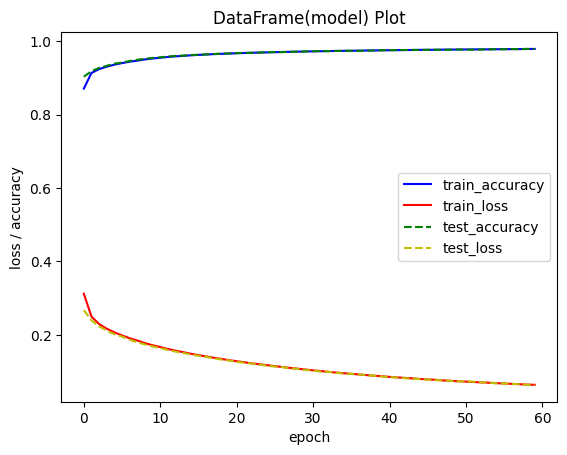

In [7]:
plt.plot(history.history['accuracy'],'b-')
plt.plot(history.history['loss'],'r-')
plt.plot(history.history['val_accuracy'],'g--')
plt.plot(history.history['val_loss'],'y--')

plt.title('DataFrame(model) Plot')
plt.ylabel('loss / accuracy')
plt.xlabel('epoch')
plt.legend(['train_accuracy','train_loss','test_accuracy', 'test_loss'])
plt.show()

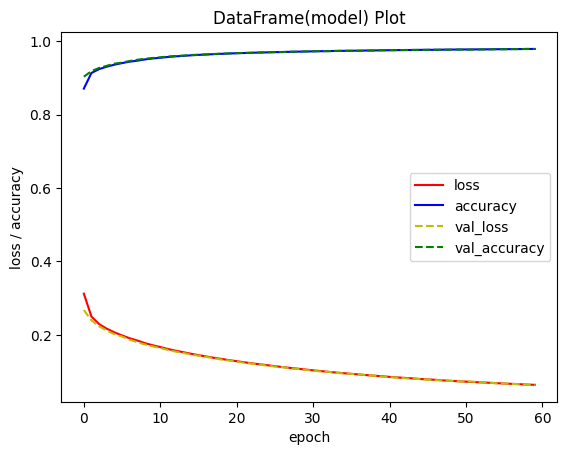

In [8]:
plt.plot(history.history['loss'],'r-')
plt.plot(history.history['accuracy'],'b-')
plt.plot(history.history['val_loss'],'y--')
plt.plot(history.history['val_accuracy'],'g--')
plt.title('DataFrame(model) Plot')
plt.ylabel('loss / accuracy')
plt.xlabel('epoch')
plt.legend(['loss', 'accuracy','val_loss','val_accuracy'])
plt.show()

In [9]:
test_generator = testGenerator("data/membrane/test")
model = unet()
model.load_weights("unet_membrane.hdf5")
results = model.predict(test_generator,30,verbose=1)

30/30 [==============================] - 26s 823ms/step


0


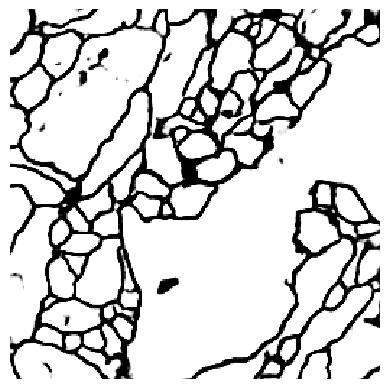

1


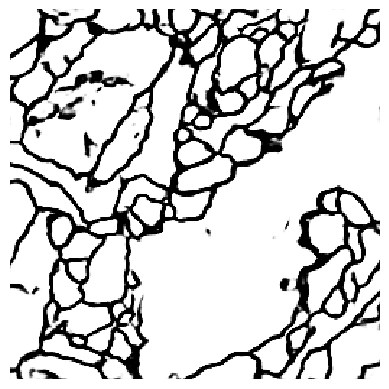

2


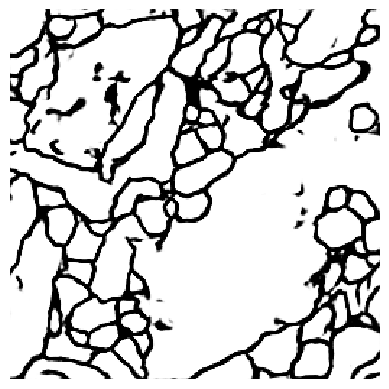

3


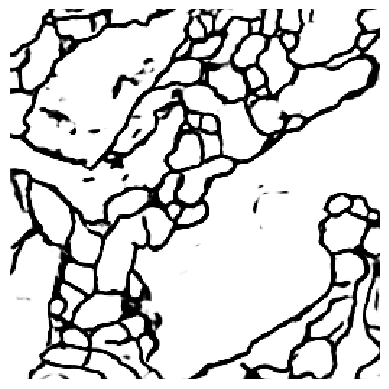

4


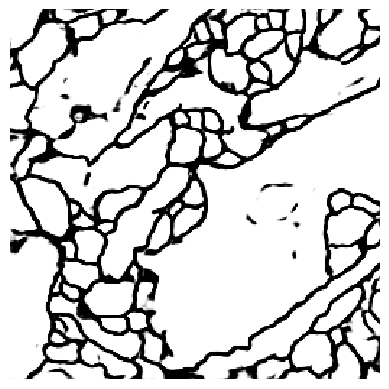

5


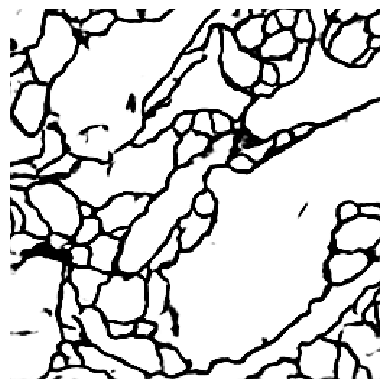

6


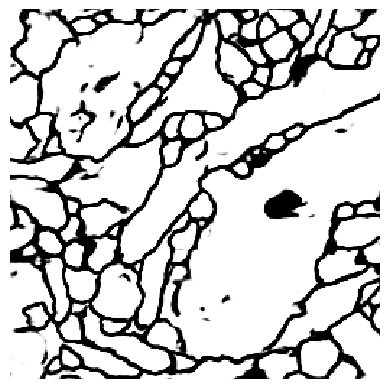

7


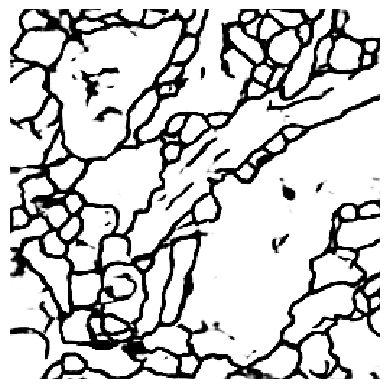

8


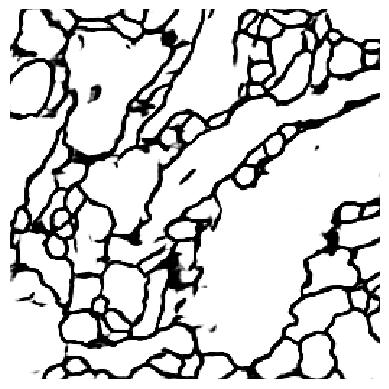

9


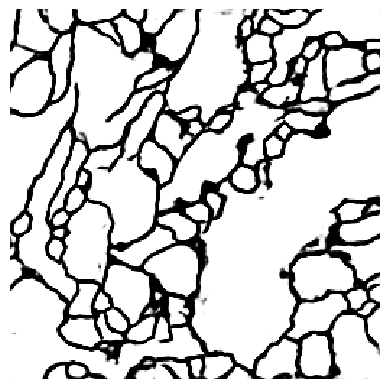

10


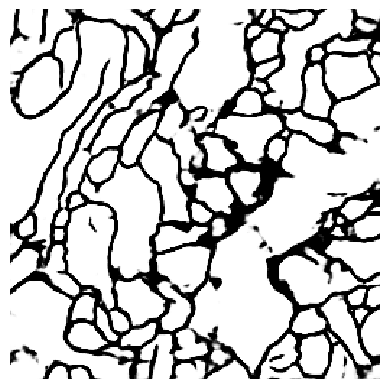

11


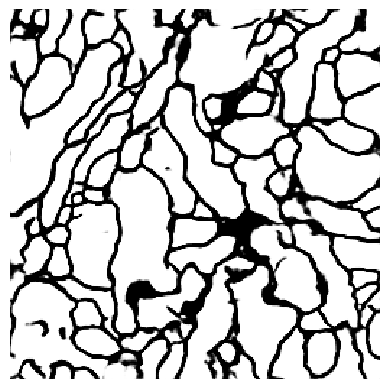

12


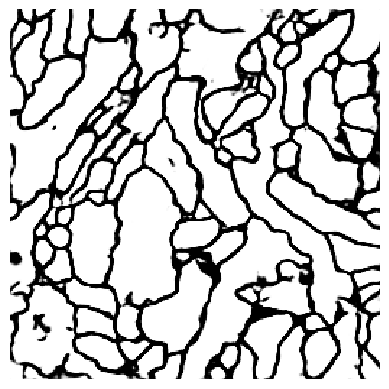

13


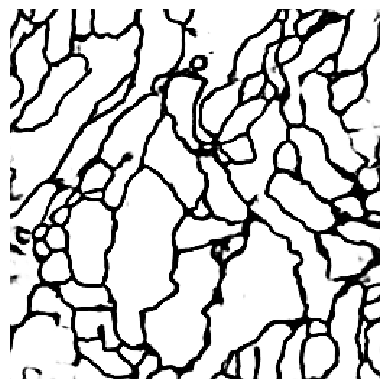

14


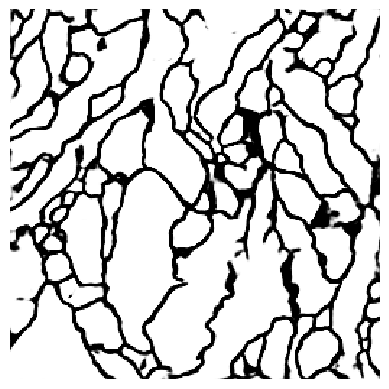

15


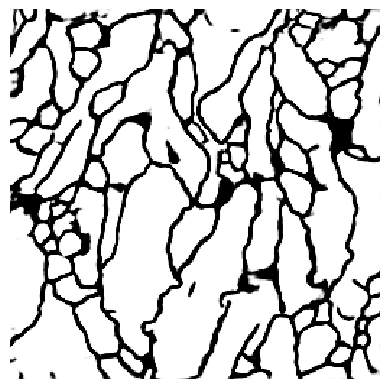

16


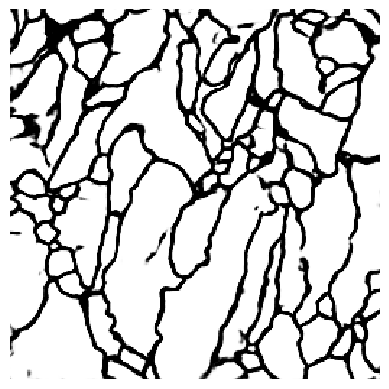

17


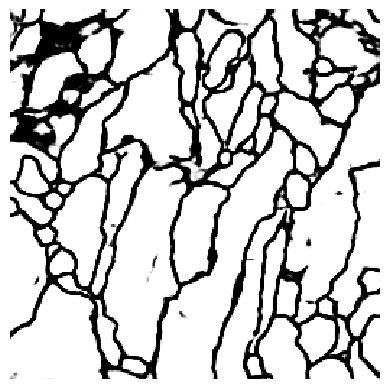

18


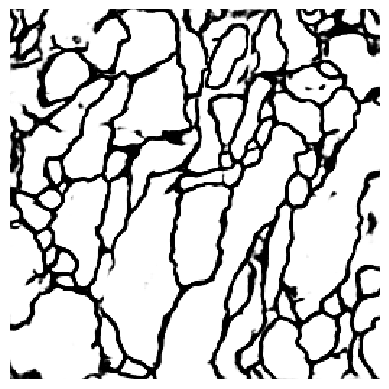

19


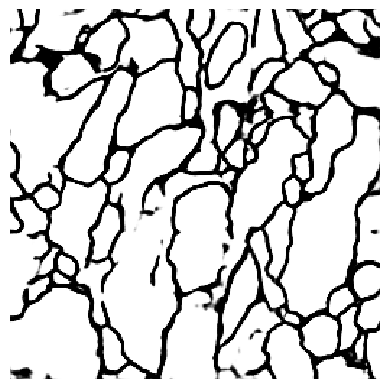

20


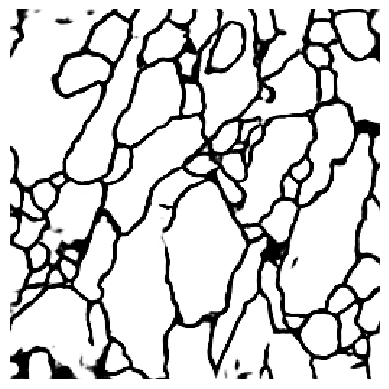

21


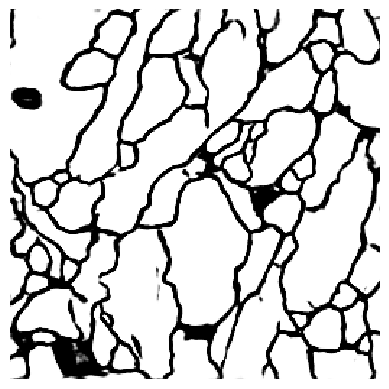

22


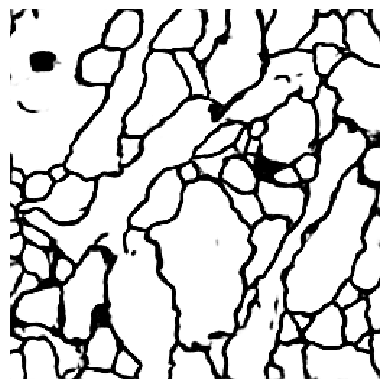

23


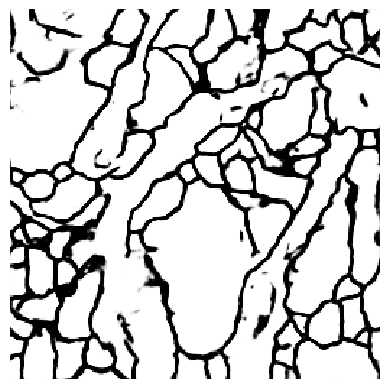

24


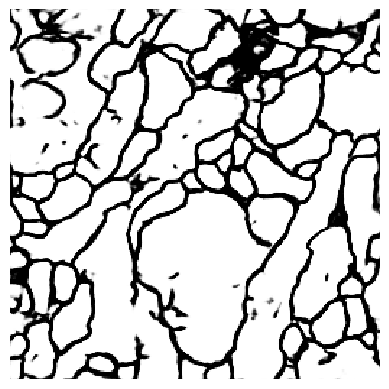

25


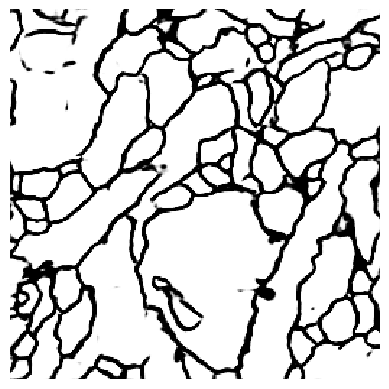

26


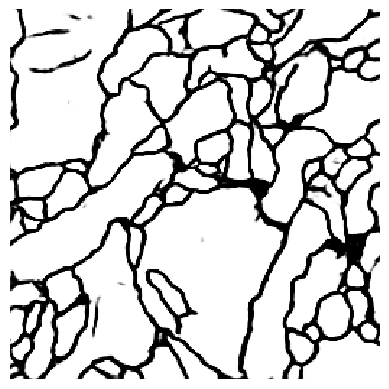

27


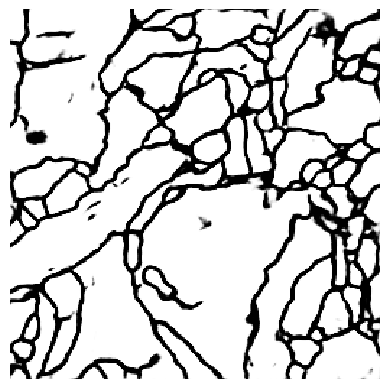

28


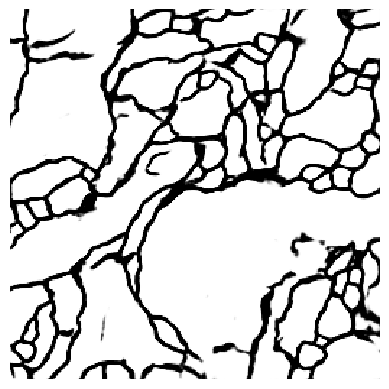

29


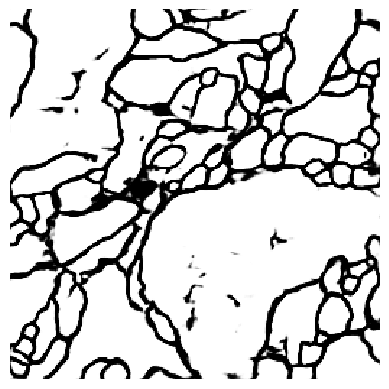

In [10]:
for i, item in enumerate(results):
    img =  item[:,:,0]
    print(i)
    plt.axis('off')
    plt.imshow(img, interpolation='nearest',cmap='gray')

    plt.show()

In [11]:

for i, item in enumerate(results):
    img =  item[:,:,0]
    #Change the code below for a black and white photo
    matplotlib.pyplot.imsave(os.path.join("./data/membrane/valid","%d_valid.png"%i),img,cmap=matplotlib.cm.gray)
    #matplotlib.pyplot.imsave(os.path.join("./data/membrane/test","%d_predict.png"%i),img)


for repeat result run this code

In [ ]:
"""
for x in range(10):
  test_generator = testGenerator("data/membrane/test")
  model = unet()
  model.load_weights("unet_membrane.hdf5")
  results = model.predict_generator(test_generator,30,verbose=1)
  for i, item in enumerate(results):
    img =  item[:,:,0]
    #Change the code below for a black and white photo
    matplotlib.pyplot.imsave(os.path.join("./data/membrane/test","%d_predict_%d.png"%i%x),img,cmap=matplotlib.cm.gray)
    #matplotlib.pyplot.imsave(os.path.join("./data/membrane/test","%d_predict_%d.png"%i%x),img)
"""